<a href="https://colab.research.google.com/github/Timothydatasciencegit/Data-Science-Code/blob/main/FC25__MALE_PLAYERS_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **FC25 Player Analysis**: Clustering Players, Team insights and Predicting Player Performance

Welcome to my FC25 analysis! This notebook analyzes FC25 player data to discover player archetypes using Clustering, exploring insights for some teams and finally predicting overall ratings (OVR) using Machine Learning. We will be exploring attributes that define player types and showcase features that contribute the most to overall player performance!

##Data Preparation
First we load the dataset and perform cleaning. We do this to make sure the quality of the data is excellent before attempting any analysis to ensure that the output/results aren't negatively affected.

In [ ]:
import pandas as pd
from google.colab import drive
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
fifa_df = pd.read_csv('/content/drive/MyDrive/male_players.csv')
fifa_df.head()

,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,...,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,...,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,...,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,...,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,...,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [ ]:
fifa_df.columns #View all columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Rank', 'Name', 'OVR', 'PAC', 'SHO',
       'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint Speed',
       'Positioning', 'Finishing', 'Shot Power', 'Long Shots', 'Volleys',
       'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
       'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility',
       'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions',
       'Heading Accuracy', 'Def Awareness', 'Standing Tackle',
       'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression',
       'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height',
       'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes'],
      dtype='object')

In [ ]:
#get the number of missing data points per column
missing_values_count = fifa_df.isnull().sum()

#look at the num of missing points in the first ten columns
print(missing_values_count)

Unnamed: 0.1                 0
Unnamed: 0                   0
Rank                         0
Name                         0
OVR                          0
PAC                          0
SHO                          0
PAS                          0
DRI                          0
DEF                          0
PHY                          0
Acceleration                 0
Sprint Speed                 0
Positioning                  0
Finishing                    0
Shot Power                   0
Long Shots                   0
Volleys                      0
Penalties                    0
Vision                       0
Crossing                     0
Free Kick Accuracy           0
Short Passing                0
Long Passing                 0
Curve                        0
Dribbling                    0
Agility                      0
Balance                      0
Reactions                    0
Ball Control                 0
Composure                    0
Interceptions                0
Heading 

In [ ]:
fifa_df = fifa_df.drop(columns=['Unnamed: 0'])
fifa_df = fifa_df.drop(columns=['Unnamed: 0.1']) #Drop all of these columns
fifa_df = fifa_df.drop(columns=['url'])
fifa_df = fifa_df.drop(columns=['GK Diving'])
fifa_df = fifa_df.drop(columns=['GK Handling'])
fifa_df = fifa_df.drop(columns=['GK Kicking'])
fifa_df = fifa_df.drop(columns=['GK Positioning'])
fifa_df = fifa_df.drop(columns=['GK Reflexes'])
fifa_df.head()

,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,...,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style
0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,...,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R..."
1,2,Rodri,91,66,80,86,84,87,85,65,...,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P..."
2,4,Erling Haaland,91,88,92,70,81,45,88,80,...,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,..."
3,5,Jude Bellingham,90,80,87,83,88,78,83,81,...,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T..."
4,7,Vini Jr.,90,95,84,81,91,29,69,95,...,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To..."


In [ ]:
df = fifa_df.fillna(0) #fill in na's with 0
df

,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,...,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style
0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,...,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R..."
1,2,Rodri,91,66,80,86,84,87,85,65,...,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P..."
2,4,Erling Haaland,91,88,92,70,81,45,88,80,...,3,Left,"195cm / 6'5""",94kg / 207lb,0,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,..."
3,5,Jude Bellingham,90,80,87,83,88,78,83,81,...,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T..."
4,7,Vini Jr.,90,95,84,81,91,29,69,95,...,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16156,17717,Engson Singh,47,31,45,47,52,34,45,32,...,2,Right,"169cm / 5'7""",62kg / 137lb,CM,21,India,ISL,Mohun Bagan SG,0
16157,17717,Ousmane Sylla,47,67,38,46,45,40,55,66,...,2,Right,"176cm / 5'9""",74kg / 163lb,0,23,Senegal,MLS,Houston Dynamo,0
16158,17717,Wei Feng,47,57,47,38,50,43,49,55,...,2,Right,"181cm / 5'11""",69kg / 152lb,0,22,China PR,CSL,Changchun Yatai,0
16159,17717,Won Hui Do,47,66,35,46,46,41,64,69,...,2,Right,"187cm / 6'2""",71kg / 157lb,0,19,Korea Republic,K League 1,Jeju United,0


In [ ]:
#get the number of missing data points per column
missing_values_count = df.isnull().sum()

#look at the num of missing points in the first ten columns
print(missing_values_count)

Rank                     0
Name                     0
OVR                      0
PAC                      0
SHO                      0
PAS                      0
DRI                      0
DEF                      0
PHY                      0
Acceleration             0
Sprint Speed             0
Positioning              0
Finishing                0
Shot Power               0
Long Shots               0
Volleys                  0
Penalties                0
Vision                   0
Crossing                 0
Free Kick Accuracy       0
Short Passing            0
Long Passing             0
Curve                    0
Dribbling                0
Agility                  0
Balance                  0
Reactions                0
Ball Control             0
Composure                0
Interceptions            0
Heading Accuracy         0
Def Awareness            0
Standing Tackle          0
Sliding Tackle           0
Jumping                  0
Stamina                  0
Strength                 0
A

In [ ]:
df.columns #view the columns in the dataset

Index(['Rank', 'Name', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY',
       'Acceleration', 'Sprint Speed', 'Positioning', 'Finishing',
       'Shot Power', 'Long Shots', 'Volleys', 'Penalties', 'Vision',
       'Crossing', 'Free Kick Accuracy', 'Short Passing', 'Long Passing',
       'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball Control',
       'Composure', 'Interceptions', 'Heading Accuracy', 'Def Awareness',
       'Standing Tackle', 'Sliding Tackle', 'Jumping', 'Stamina', 'Strength',
       'Aggression', 'Position', 'Weak foot', 'Skill moves', 'Preferred foot',
       'Height', 'Weight', 'Alternative positions', 'Age', 'Nation', 'League',
       'Team', 'play style'],
      dtype='object')

In [ ]:
fifa_df.head()

,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,...,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style
0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,...,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R..."
1,2,Rodri,91,66,80,86,84,87,85,65,...,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P..."
2,4,Erling Haaland,91,88,92,70,81,45,88,80,...,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,..."
3,5,Jude Bellingham,90,80,87,83,88,78,83,81,...,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T..."
4,7,Vini Jr.,90,95,84,81,91,29,69,95,...,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To..."


In [ ]:
df = fifa_df.set_index('Rank') #set rank as index
print(df.head(3))

                Name  OVR  PAC  SHO  PAS  DRI  DEF  PHY  Acceleration  \
Rank                                                                    
1      Kylian Mbappé   91   97   90   80   92   36   78            97   
2              Rodri   91   66   80   86   84   87   85            65   
4     Erling Haaland   91   88   92   70   81   45   88            80   

      Sprint Speed  ...  Skill moves  Preferred foot        Height  \
Rank                ...                                              
1               97  ...            5           Right  182cm / 6'0"   
2               66  ...            3           Right  191cm / 6'3"   
4               94  ...            3            Left  195cm / 6'5"   

            Weight  Alternative positions  Age  Nation            League  \
Rank                                                                       
1     75kg / 165lb                     LW   25  France  LALIGA EA SPORTS   
2     82kg / 181lb                     CM   28   Spain 

##Data Exploration
Next we will explore the data before modeling to learn more about the dataset.

In [ ]:
df.describe() #view summary statistics for column values

,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,...,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Weak foot,Skill moves,Age
count,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,...,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000
mean,66.172390,68.149558,54.146835,58.434874,63.599158,50.591981,65.241755,64.778727,64.812264,50.983293,...,47.018873,48.879587,46.635542,66.173442,63.426892,65.317121,56.342986,2.952045,2.393292,25.790545
std,6.761979,10.612153,13.740389,9.660646,9.262399,16.323879,9.509657,15.478648,15.258747,19.903044,...,20.408949,20.979117,20.509403,11.755204,16.450390,12.370667,16.771384,0.677057,0.783739,4.662681
min,47.000000,29.000000,20.000000,25.000000,29.000000,15.000000,32.000000,15.000000,15.000000,3.000000,...,5.000000,9.000000,8.000000,27.000000,15.000000,26.000000,11.000000,1.000000,1.000000,17.000000
25%,62.000000,62.000000,45.000000,52.000000,58.000000,36.000000,59.000000,57.000000,57.000000,40.000000,...,30.000000,29.000000,27.000000,58.000000,57.000000,58.000000,46.000000,3.000000,2.000000,22.000000
50%,66.000000,69.000000,57.000000,59.000000,64.000000,55.000000,66.000000,68.000000,68.000000,57.000000,...,53.000000,57.000000,54.000000,68.000000,67.000000,66.000000,60.000000,3.000000,2.000000,25.000000
75%,70.000000,75.000000,64.000000,65.000000,70.000000,64.000000,72.000000,75.000000,75.000000,65.000000,...,64.000000,66.000000,63.000000,75.000000,74.000000,74.000000,69.000000,3.000000,3.000000,29.000000
max,91.000000,97.000000,93.000000,94.000000,92.000000,89.000000,91.000000,97.000000,97.000000,96.000000,...,92.000000,91.000000,88.000000,95.000000,95.000000,95.000000,95.000000,5.000000,5.000000,44.000000


In [ ]:
df.info() #View columns and Dtypes

<class 'pandas.core.frame.DataFrame'>
Index: 16161 entries, 1 to 17717
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Name                   16161 non-null  object
 1   OVR                    16161 non-null  int64 
 2   PAC                    16161 non-null  int64 
 3   SHO                    16161 non-null  int64 
 4   PAS                    16161 non-null  int64 
 5   DRI                    16161 non-null  int64 
 6   DEF                    16161 non-null  int64 
 7   PHY                    16161 non-null  int64 
 8   Acceleration           16161 non-null  int64 
 9   Sprint Speed           16161 non-null  int64 
 10  Positioning            16161 non-null  int64 
 11  Finishing              16161 non-null  int64 
 12  Shot Power             16161 non-null  int64 
 13  Long Shots             16161 non-null  int64 
 14  Volleys                16161 non-null  int64 
 15  Penalties              1

In [ ]:
df.columns = df.columns.str.strip() #remove spaces from columns

In [ ]:
df['Nation'].value_counts()#count unique values in the nations column

,count
Nation,
England,1491
Germany,1105
Spain,893
Argentina,861
France,728
...,...
Puerto Rico,1
Somalia,1
Rwanda,1


In [ ]:
df.isna().sum() #view if there are any null values in the dataset

,0
Name,0
OVR,0
PAC,0
SHO,0
PAS,0
DRI,0
DEF,0
PHY,0
Acceleration,0
Sprint Speed,0


In [ ]:
duplicate_rows = df[df.duplicated()] #search the number of duplicate rows. 0 duplicated rows and 55 columns
print('Number of Dduplicate rows: ',duplicate_rows.shape)

Number of Dduplicate rows:  (0, 49)


In [ ]:
#make a subset for ratings 86 and above
sub = df[(df['OVR']>=86)] #make a subset for 86 rated and above
high_ovr = sub[sub['OVR'] < 99]

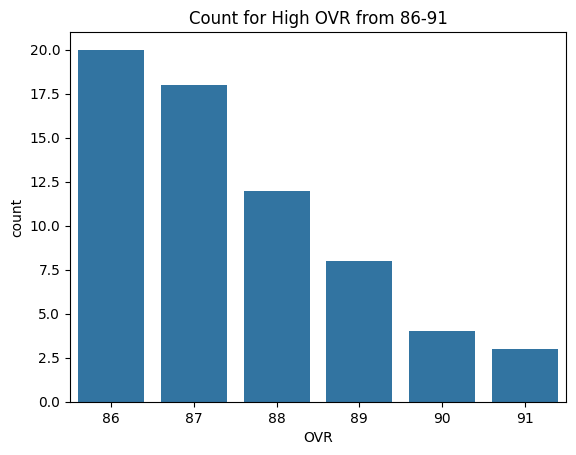

In [ ]:
sns.countplot(data=high_ovr, x='OVR') #make a countplot for the 86 and above overalls
plt.title('Count for High OVR from 86-91')
plt.show()

In [ ]:
#86 - 89 rated players
for label, row in high_ovr.iterrows():
  if row['OVR'] < 90:
    print(row['Name'])

Martin Ødegaard
Gianluigi Donnarumma
Alisson
Thibaut Courtois
Lautaro Martínez
Virgil van Dijk
Marc-André ter Stegen
Mohamed Salah
Phil Foden
Lionel Messi
Antoine Griezmann
Rúben Dias
Robert Lewandowski
Federico Valverde
Ederson
Bernardo Silva
Jan Oblak
Antonio Rüdiger
Florian Wirtz
Gregor Kobel
William Saliba
Victor Osimhen
Jamal Musiala
Bukayo Saka
Paulo Dybala
Theo Hernández
Neymar Jr
Declan Rice
Frenkie de Jong
Mike Maignan
Bruno Fernandes
Heung Min Son
Marquinhos
Alessandro Bastoni
İlkay Gündoğan
Emiliano Martínez
Nicolò Barella
Yann Sommer
Cristiano Ronaldo
Gabriel
Granit Xhaka
Rodrygo
João Cancelo
Rafael Leão
Grimaldo
Luka Modrić
Alexis Mac Allister
Carvajal
Ousmane Dembélé
Trent Alexander-Arnold
Pedri
Jonathan Tah
Karim Benzema
Bremer
Joshua Kimmich
Unai Simón
Manuel Neuer
Hakan Çalhanoğlu


In [ ]:
#Players 90 and Above
for label, row in high_ovr.iterrows():
  if row['OVR'] >= 90:
    print(row['Name'])

Kylian Mbappé
Rodri
Erling Haaland
Jude Bellingham
Vini Jr.
Kevin De Bruyne
Harry Kane


##Custom Functions
Here we create Custom Player lookup functions to identify players who matcher user defined attribute thresholds. This is useful for gamers scouting for Career Mode planning or even Ultimate Team Card packing.

In [ ]:
#function that returns players with rating listed
def rating_search(x):
  for label, row in df.iterrows():
    if row['OVR'] == x:
      print(row['Name'])



In [ ]:
rating_search(85)

David Alaba
Ronald Araujo
Julian Brandt
Éder Militão
Bruno Guimarães
Alexander Isak
N'Golo Kanté
Jules Koundé
Khvicha Kvaratskhelia
Vitinha
James Maddison
Riyad Mahrez
Giorgi Mamardashvili
Mikel Merino
Sergej Milinković-Savić
Loïs Openda
Palhinha
Cole Palmer
Andrew Robertson
Leroy Sané
Nico Schlotterbeck
John Stones
Aurélien Tchouaméni
Diogo Jota
Sandro Tonali
Ollie Watkins
Nico Williams


In [ ]:
#Rising Youngsters
for label, row in df.iterrows():
  if row['Age'] <= 21 and row['OVR'] >= 80:
    print(row['Name'])

Jude Bellingham
Florian Wirtz
Jamal Musiala
Pedri
Eduardo Camavinga
Gavi
Xavi Simons
Savinho
Destiny Udogie
Balde
Lamine Yamal
Malo Gusto
Warren Zaïre-Emery


In [ ]:
#search players with PAC of x
def fastest_search(x):
  for label, row in df.iterrows():
    if row['PAC'] == x:
      print(row['Name'])

In [ ]:
fastest_search(95)

Vini Jr.
Theo Hernández
Moussa Diaby
Alphonso Davies
Yankuba Minteh


In [ ]:
#Search players with SHO of x
def shoot_search(x):
  for label, row in df.iterrows():
    if row['SHO'] == x:
      print(row['Name'])



In [ ]:
shoot_search(88)

Lautaro Martínez
Antoine Griezmann
Robert Lewandowski
Cristiano Ronaldo


In [ ]:
#scan through each row and return all players with 5 star skill moves
for label, row in df.iterrows():
  if row['Skill moves'] == 5:
    print(row['Name'])

Kylian Mbappé
Vini Jr.
Martin Ødegaard
Jamal Musiala
Paulo Dybala
Neymar Jr
Cristiano Ronaldo
Rafael Leão
Ousmane Dembélé
Khvicha Kvaratskhelia
Riyad Mahrez
Kingsley Coman
Christopher Nkunku
Ángel Di María
Lucas Paquetá
Jadon Sancho
Luciano Acosta
Marcus Rashford
Wilfried Zaha
Roberto Firmino
João Félix
Nuno Santos
David Neres
Allan Saint-Maximin
Hakim Ziyech
Noa Lang
Antony
Marcelino Moreno
Chidera Ejuke
Amine Harit
Rayan Cherki
Jota
Georginio Rutter
Eduardo Salvio
Hernán López Muñoz
Osame Sahraoui
Cesinha
Daniel-Kofi Kyereh
Xherdan Shaqiri
Elias Saad
Taha Abdi Ali


In [ ]:
df[df['Name']=='Viktor Gyökeres'] # View Viktor Gyokeres Stats

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
Rank,,,,,,,,,,,,,,,,,,,,,
149,Viktor Gyökeres,84,90,83,67,80,36,91,88,92,...,Sweden,Liga Portugal,Sporting CP,Press Proven,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


##Team-Level Insights
Here we explore players from individual clubs exploring how player statistics vary by team.

In [ ]:
#return all liverpool players

LFC = df[df['Team']=='Liverpool']
print(LFC['Name'])

Rank
15                      Alisson
20              Virgil van Dijk
22                Mohamed Salah
79          Alexis Mac Allister
86       Trent Alexander-Arnold
101            Andrew Robertson
101                  Diogo Jota
149             Federico Chiesa
149                   Luis Díaz
222                  Cody Gakpo
222             Ibrahima Konaté
322                Darwin Núñez
458          Dominik Szoboszlai
577                 Wataru Endo
577                   Joe Gomez
736                Curtis Jones
970              Harvey Elliott
970            Ryan Gravenberch
1218          Caoimhin Kelleher
1218      Konstantinos Tsimikas
1888              Conor Bradley
1888             Jarell Quansah
3521               Tyler Morton
5037            Diego Rodríguez
5902               Diego García
6884           Agustín Cayetano
6884            Vítězslav Jaroš
6884                Lucas Lemos
6884       Sebastián Lentinelly
9009           Agustín González
10108               Kevin Amaro
101

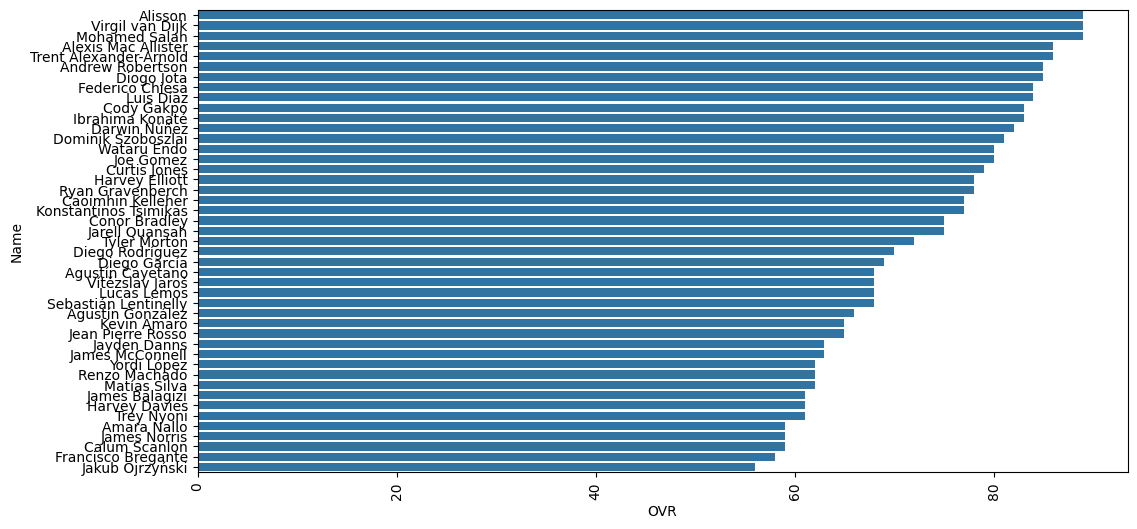

In [ ]:
#plot the liverpool players and their overall
plt.figure(figsize=(12,6))
sns.barplot(data=LFC, x='OVR', y='Name')
plt.xticks(rotation=90)
plt.show()


In [ ]:
LFC_ovr = LFC.loc[:,['Name','OVR']] #liverpool names with overall
print(LFC_ovr)

                         Name  OVR
Rank                              
15                    Alisson   89
20            Virgil van Dijk   89
22              Mohamed Salah   89
79        Alexis Mac Allister   86
86     Trent Alexander-Arnold   86
101          Andrew Robertson   85
101                Diogo Jota   85
149           Federico Chiesa   84
149                 Luis Díaz   84
222                Cody Gakpo   83
222           Ibrahima Konaté   83
322              Darwin Núñez   82
458        Dominik Szoboszlai   81
577               Wataru Endo   80
577                 Joe Gomez   80
736              Curtis Jones   79
970            Harvey Elliott   78
970          Ryan Gravenberch   78
1218        Caoimhin Kelleher   77
1218    Konstantinos Tsimikas   77
1888            Conor Bradley   75
1888           Jarell Quansah   75
3521             Tyler Morton   72
5037          Diego Rodríguez   70
5902             Diego García   69
6884         Agustín Cayetano   68
6884          Vítězs

In [ ]:
LFC_df = pd.DataFrame(LFC)
pd.set_option('display.max_columns', None)
LFC_df

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
15,Alisson,89,86,85,85,89,56,90,60,49,13,13,64,14,20,23,66,17,18,60,58,19,27,40,37,87,42,66,11,29,15,19,16,82,32,78,27,GK,3,1,Right,"193cm / 6'4""",91kg / 201lb,NaN,31,Brazil,Premier League,Liverpool,"Deflector+, 1v1 Close Down, Far Throw",https://www.ea.com/games/ea-sports-fc/ratings/...,86.0,85.0,85.0,90.0,89.0
20,Virgil van Dijk,89,78,60,71,71,89,86,66,87,47,52,81,64,45,62,67,53,70,80,86,60,70,54,50,88,77,90,88,87,90,91,86,89,72,93,85,CB,3,2,Right,"193cm / 6'4""",92kg / 203lb,NaN,33,Holland,Premier League,Liverpool,"Aerial+, Anticipate, Block, Bruiser, Jockey, L...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
22,Mohamed Salah,89,89,87,82,88,45,75,89,89,92,90,82,84,83,81,85,80,69,86,77,84,88,89,91,93,86,88,55,59,38,43,41,79,87,73,63,RW,3,4,Left,"175cm / 5'9""",72kg / 159lb,RM,32,Egypt,Premier League,Liverpool,"Finesse Shot+, Chip Shot, Rapid, Trivela",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
79,Alexis Mac Allister,86,69,82,85,84,76,76,71,67,80,79,88,82,77,86,86,79,82,87,86,83,84,82,83,85,86,84,78,61,77,79,73,72,87,69,83,CM,3,3,Right,"176cm / 5'9""",72kg / 159lb,CDM,25,Argentina,Premier League,Liverpool,"Pinged Pass+, Dead Ball, Incisive Pass, Power ...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
86,Trent Alexander-Arnold,86,75,72,90,80,80,74,72,78,79,64,85,76,68,66,89,93,85,89,92,88,79,73,72,85,85,82,84,69,78,82,78,75,89,68,69,RB,4,3,Right,"180cm / 5'11""",72kg / 159lb,NaN,25,England,Premier League,Liverpool,"Whipped Pass+, Dead Ball, Incisive Pass, Long ...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
101,Andrew Robertson,85,78,61,82,79,81,78,79,78,78,55,76,65,32,55,82,87,71,83,76,82,78,75,74,85,82,83,81,67,82,83,81,76,93,67,85,LB,2,3,Left,"178cm / 5'10""",64kg / 141lb,NaN,30,Scotland,Premier League,Liverpool,"Relentless+, Rapid, Whipped Pass",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
101,Diogo Jota,85,82,82,75,84,57,79,85,80,88,85,86,76,79,69,78,73,58,77,72,77,83,86,87,88,85,83,56,86,53,57,45,91,80,75,85,ST,5,4,Right,"178cm / 5'10""",70kg / 154lb,LW,27,Portugal,Premier League,Liverpool,"Rapid, Relentless",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
149,Federico Chiesa,84,93,83,76,86,52,75,92,93,84,84,86,83,84,62,77,75,62,78,76,78,87,90,84,84,83,82,54,53,51,51,48,76,84,70,74,RW,4,4,Right,"175cm / 5'9""",70kg / 154lb,"LW, ST, RM",26,Italy,Premier League,Liverpool,"Finesse Shot, Flair, Quick Step, Rapid, Trivela",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
149,Luis Díaz,84,90,80,75,87,39,75,91,90,83,80,84,81,81,63,77,76,58,76,71,77,89,88,77,83,87,82,28,64,35,42,34,80,87,69,74,LW,4,4,Right,"180cm / 5'11""",73kg / 161lb,"RW, LM",27,Colombia,Premier League,Liverpool,"Flair, Quick Step, Technical",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [ ]:
LFC_df['play style'] = LFC_df['play style'].str.replace(',','') #replace the , in play style with an empty space

In [ ]:
LFC_ovr = LFC_df[['Name','play style']]
LFC_ovr = pd.DataFrame(LFC_ovr)
LFC_ovr

,Name,play style
Rank,,
15,Alisson,Deflector+ 1v1 Close Down Far Throw
20,Virgil van Dijk,Aerial+ Anticipate Block Bruiser Jockey Long B...
22,Mohamed Salah,Finesse Shot+ Chip Shot Rapid Trivela
79,Alexis Mac Allister,Pinged Pass+ Dead Ball Incisive Pass Power Sho...
86,Trent Alexander-Arnold,Whipped Pass+ Dead Ball Incisive Pass Long Bal...
101,Andrew Robertson,Relentless+ Rapid Whipped Pass
101,Diogo Jota,Rapid Relentless
149,Federico Chiesa,Finesse Shot Flair Quick Step Rapid Trivela
149,Luis Díaz,Flair Quick Step Technical


In [ ]:
LFC_speed = LFC.groupby(['Name', 'PAC', 'Acceleration', 'Sprint Speed'], as_index=False)['PAC'].sum() #Groupby highest pace
LFC_speed.sort_values(by = 'PAC', ascending=False)

,Name,Acceleration,Sprint Speed,PAC
16,Federico Chiesa,92,93,93
32,Luis Díaz,91,90,90
11,Darwin Núñez,88,92,90
34,Mohamed Salah,89,89,89
3,Alisson,60,49,86
14,Diogo Jota,85,80,82
8,Cody Gakpo,84,81,82
28,Joe Gomez,75,87,82
15,Dominik Szoboszlai,76,87,82
9,Conor Bradley,81,83,82


In [ ]:
LFC_shoot = LFC.groupby(['Name', 'SHO' ,'Finishing', 'Shot Power', 'Long Shots'], as_index=False)['SHO'].sum() #groupby highest shot stat
LFC_shoot.sort_values(by = 'SHO', ascending=False)

,Name,Finishing,Shot Power,Long Shots,SHO
34,Mohamed Salah,90,82,84,87
3,Alisson,13,64,14,85
8,Cody Gakpo,83,86,83,83
16,Federico Chiesa,84,86,83,83
2,Alexis Mac Allister,79,88,82,82
14,Diogo Jota,85,86,76,82
15,Dominik Szoboszlai,77,89,78,80
11,Darwin Núñez,79,86,77,80
32,Luis Díaz,80,84,81,80
36,Ryan Gravenberch,76,78,79,76


In [ ]:
LFC_dri = LFC.groupby(['Name', 'DRI', 'Ball Control', 'Dribbling', 'Agility', 'Balance', 'Reactions'], as_index=False)['DRI'].sum()
LFC_dri.sort_values(by = 'DRI', ascending=False)

,Name,Ball Control,Dribbling,Agility,Balance,Reactions,DRI
3,Alisson,42,27,40,37,87,89
34,Mohamed Salah,86,88,89,91,93,88
32,Luis Díaz,87,89,88,77,83,87
16,Federico Chiesa,83,87,90,84,84,86
2,Alexis Mac Allister,86,84,82,83,85,84
14,Diogo Jota,85,83,86,87,88,84
8,Cody Gakpo,85,86,75,67,81,83
36,Ryan Gravenberch,83,84,77,69,74,81
19,Harvey Elliott,79,81,90,90,75,81
10,Curtis Jones,82,83,76,72,79,81


In [ ]:
Man_utd = df[df['Team']=='Man Utd'] #manunited players
print(Man_utd['Name'])

Rank
57          Bruno Fernandes
149        Matthijs de Ligt
149       Lisandro Martínez
149                Casemiro
222             André Onana
322             Diogo Dalot
322               Luke Shaw
458       Noussair Mazraoui
458         Marcus Rashford
458           Manuel Ugarte
577           Harry Maguire
736      Alejandro Garnacho
736          Joshua Zirkzee
970       Christian Eriksen
970          Rasmus Højlund
970         Victor Lindelöf
970             Mason Mount
970               Leny Yoro
1218          Kobbie Mainoo
1218                 Antony
1525         Altay Bayındır
1525         Tyrell Malacia
1888            Amad Diallo
2318            Jonny Evans
11203        Ethan Wheatley
13955           Daniel Gore
14644           Harry Amass
15274          Toby Collyer
15274         Louis Jackson
15274            Sam Mather
16153       Habeeb Ogunneye
16470            Dermot Mee
Name: Name, dtype: object


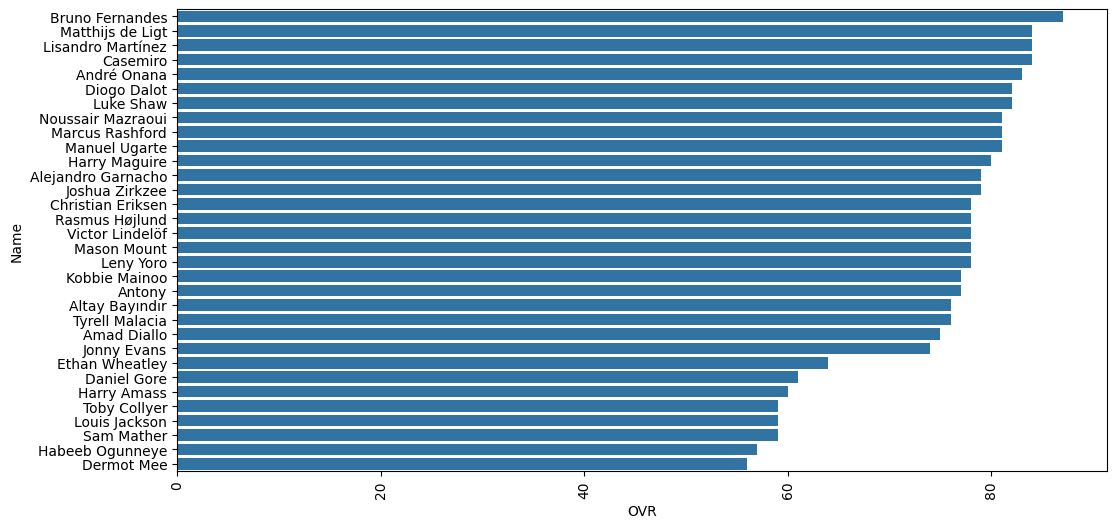

In [ ]:
#plot overall of united players
plt.figure(figsize=(12,6))
sns.barplot(data=Man_utd, x='OVR', y='Name')
plt.xticks(rotation=90)
plt.show()

In [ ]:
ovr = Man_utd.loc[:,['Name','OVR']]
Man_utd_ovr = pd.DataFrame(ovr)
Man_utd_ovr

,Name,OVR
Rank,,
57,Bruno Fernandes,87
149,Matthijs de Ligt,84
149,Lisandro Martínez,84
149,Casemiro,84
222,André Onana,83
322,Diogo Dalot,82
322,Luke Shaw,82
458,Noussair Mazraoui,81
458,Marcus Rashford,81


In [ ]:
Man_utd.columns

Index(['Name', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration',
       'Sprint Speed', 'Positioning', 'Finishing', 'Shot Power', 'Long Shots',
       'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
       'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility',
       'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions',
       'Heading Accuracy', 'Def Awareness', 'Standing Tackle',
       'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression',
       'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height',
       'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes'],
      dtype='object')

In [ ]:
Man_utd['play style'] = Man_utd['play style'].str.replace(',','')

/tmp/ipython-input-246299412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Man_utd['play style'] = Man_utd['play style'].str.replace(',','')


In [ ]:
Man_U_play_styles = Man_utd[['Name','play style']]
Man_U_play_styles = pd.DataFrame(Man_U_play_styles)
Man_U_play_styles

,Name,play style
Rank,,
57,Bruno Fernandes,Long Ball Pass+ Dead Ball First Touch Flair In...
149,Matthijs de Ligt,Block Bruiser Long Ball Pass Power Shot
149,Lisandro Martínez,Bruiser Long Ball Pass Slide Tackle
149,Casemiro,Block Bruiser Long Ball Pass Slide Tackle
222,André Onana,1v1 Close Down Footwork
322,Diogo Dalot,Slide Tackle Technical
322,Luke Shaw,Jockey
458,Noussair Mazraoui,Anticipate Flair Intercept Jockey Technical
458,Marcus Rashford,Power Shot+ Flair Quick Step Technical


In [ ]:
Man_utd_speed = Man_utd.groupby(['Name', 'PAC', 'Acceleration', 'Sprint Speed'], as_index=False)['PAC'].sum()
Man_utd_speed.sort_values(by = 'PAC', ascending=False)

,Name,Acceleration,Sprint Speed,PAC
23,Marcus Rashford,87,91,89
0,Alejandro Garnacho,88,84,86
10,Diogo Dalot,84,86,85
2,Amad Diallo,88,82,85
27,Rasmus Højlund,84,86,85
3,André Onana,62,60,83
4,Antony,86,78,82
1,Altay Bayındır,30,31,78
30,Tyrell Malacia,79,78,78
26,Noussair Mazraoui,83,73,78


In [ ]:
Man_shoot = Man_utd.groupby(['Name', 'SHO' ,'Finishing', 'Shot Power', 'Long Shots'], as_index=False)['SHO'].sum()
Man_shoot.sort_values(by = 'SHO', ascending=False)

,Name,Finishing,Shot Power,Long Shots,SHO
5,Bruno Fernandes,84,86,85,85
23,Marcus Rashford,80,93,80,83
16,Joshua Zirkzee,79,76,75,77
27,Rasmus Højlund,79,84,70,77
24,Mason Mount,76,80,78,77
0,Alejandro Garnacho,77,78,69,75
3,André Onana,12,65,17,75
6,Casemiro,69,82,78,74
7,Christian Eriksen,70,79,78,74
1,Altay Bayındır,10,54,11,73


In [ ]:
Man_dri = Man_utd.groupby(['Name', 'DRI', 'Ball Control', 'Dribbling', 'Agility', 'Balance', 'Reactions'], as_index=False)['DRI'].sum()
Man_dri.sort_values(by = 'DRI', ascending=False)

,Name,Ball Control,Dribbling,Agility,Balance,Reactions,DRI
3,André Onana,40,26,66,53,83,86
5,Bruno Fernandes,86,83,78,76,90,83
26,Noussair Mazraoui,84,83,86,74,79,83
16,Joshua Zirkzee,86,84,84,61,78,83
4,Antony,82,80,89,91,76,82
23,Marcus Rashford,82,84,79,69,79,82
17,Kobbie Mainoo,80,82,79,88,76,81
0,Alejandro Garnacho,80,81,87,88,77,81
2,Amad Diallo,80,79,92,87,69,80
10,Diogo Dalot,81,81,76,71,80,80


In [ ]:
RM = df[df['Team']=='Real Madrid']
print(RM['Name'])

Rank
1              Kylian Mbappé
5            Jude Bellingham
7                   Vini Jr.
16          Thibaut Courtois
32         Federico Valverde
40           Antonio Rüdiger
72                   Rodrygo
77               Luka Modrić
81                  Carvajal
101              David Alaba
101             Éder Militão
101      Aurélien Tchouaméni
149            Ferland Mendy
222        Eduardo Camavinga
322                   Brahim
458             Andriy Lunin
458            Lucas Vázquez
736            Dani Ceballos
970              Fran García
970               Arda Güler
1218                 Endrick
2882                 Vallejo
10108                Gonzalo
11203                 Jacobo
12239            Edgar Pujol
Name: Name, dtype: object


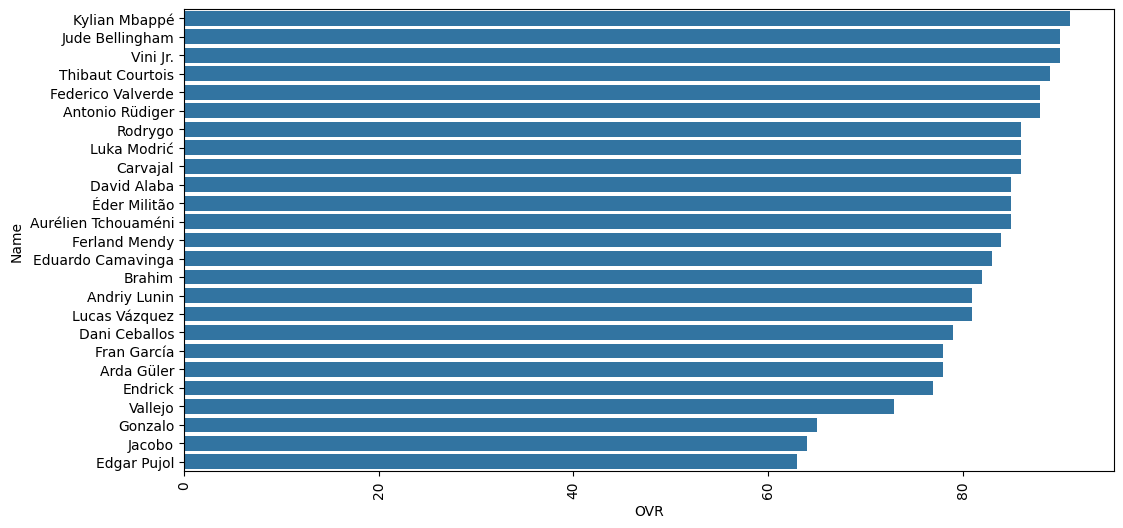

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=RM, x='OVR', y='Name')
plt.xticks(rotation=90)
plt.show()

In [ ]:
ovr = RM.loc[:,['Name','OVR']]
RM_ovr = pd.DataFrame(ovr)
RM_ovr

,Name,OVR
Rank,,
1,Kylian Mbappé,91
5,Jude Bellingham,90
7,Vini Jr.,90
16,Thibaut Courtois,89
32,Federico Valverde,88
40,Antonio Rüdiger,88
72,Rodrygo,86
77,Luka Modrić,86
81,Carvajal,86


In [ ]:
RM_styles = RM[['Name','play style']]
RM_styles = pd.DataFrame(RM_styles)
RM_styles

,Name,play style
Rank,,
1,Kylian Mbappé,"Quick Step+, Acrobatic, Finesse Shot, Flair, R..."
5,Jude Bellingham,"Relentless+, Flair, Intercept, Slide Tackle, T..."
7,Vini Jr.,"Quick Step+, Chip Shot, Finesse Shot, First To..."
16,Thibaut Courtois,"1v1 Close Down+, Cross Claimer, Far Throw"
32,Federico Valverde,"Power Shot+, Long Ball Pass, Rapid, Relentless..."
40,Antonio Rüdiger,"Bruiser+, Acrobatic, Aerial, Block, Jockey"
72,Rodrygo,"Dead Ball, Finesse Shot, Flair, Technical"
77,Luka Modrić,"Trivela+, Incisive Pass, Long Ball Pass, Techn..."
81,Carvajal,"Block, Whipped Pass"


In [ ]:
RM_speed = RM.groupby(['Name', 'PAC', 'Acceleration', 'Sprint Speed'], as_index=False)['PAC'].sum()
RM_speed.sort_values(by = 'PAC', ascending=False)

,Name,Acceleration,Sprint Speed,PAC
17,Kylian Mbappé,97,97,97
23,Vini Jr.,95,95,95
10,Endrick,91,88,89
12,Ferland Mendy,88,89,89
13,Fran García,90,89,89
20,Rodrygo,90,88,89
11,Federico Valverde,84,91,88
21,Thibaut Courtois,42,52,85
4,Brahim,85,85,85
24,Éder Militão,81,88,85


In [ ]:
RM_shoot = RM.groupby(['Name', 'SHO' ,'Finishing', 'Shot Power', 'Long Shots'], as_index=False)['SHO'].sum()
RM_shoot.sort_values(by = 'SHO', ascending=False)

,Name,Finishing,Shot Power,Long Shots,SHO
17,Kylian Mbappé,94,90,83,90
21,Thibaut Courtois,14,57,17,89
16,Jude Bellingham,90,85,86,87
23,Vini Jr.,89,81,83,84
11,Federico Valverde,78,91,87,82
20,Rodrygo,86,76,77,81
0,Andriy Lunin,8,58,7,78
19,Luka Modrić,72,79,82,76
10,Endrick,77,79,74,76
18,Lucas Vázquez,73,80,76,74


In [ ]:
RM_dri = RM.groupby(['Name', 'DRI', 'Ball Control', 'Dribbling', 'Agility', 'Balance', 'Reactions'], as_index=False)['DRI'].sum()
RM_dri.sort_values(by = 'DRI', ascending=False)

,Name,Ball Control,Dribbling,Agility,Balance,Reactions,DRI
17,Kylian Mbappé,92,93,93,82,93,92
23,Vini Jr.,90,93,94,84,86,91
21,Thibaut Courtois,23,13,63,45,88,90
16,Jude Bellingham,89,89,82,79,91,88
20,Rodrygo,87,89,87,84,84,88
19,Luka Modrić,90,84,92,92,85,87
4,Brahim,85,84,89,91,79,85
9,Eduardo Camavinga,86,84,82,81,82,84
11,Federico Valverde,88,83,77,68,89,84
2,Arda Güler,82,83,82,85,74,82


In [ ]:
print(df['OVR'].min()) #Print min and max overall rating
print(df['OVR'].max())

47
91


In [ ]:
rating_search(47)

Mohammed Aimen
Fredy Chawngthansanga
Lalchungnunga Chhangte
Hwang Seo Ung
Jo In Jung
Isaiah Jones
Kang Gyo Hoon
Kim Dong Min
Kim Myeong Jun
Kim Se Hoon
Liao Rongxiang
Min Zixi
Ning Fangze
Park Hyung Woo
Park Jin Hong
Sajad Parray
Engson Singh
Ousmane Sylla
Wei Feng
Won Hui Do
Wu Yuhang


In [ ]:
#function to return player rated 89 and up
def balon_dor(x):
  for label, row in df.iterrows():
    if x >= 89:
      print(row[['Name','OVR']])
    else:
      None


A Correlation Matrix is used to identify the relationship between the variables in the dataset.

In [ ]:
#creating a correlation matrix for the dataset
num_columns = df.select_dtypes(include=['number'])
corr_matrix = num_columns.corr()
corr_matrix = corr_matrix.round(2)
print(corr_matrix)

                     OVR   PAC   SHO   PAS   DRI   DEF   PHY  Acceleration  \
OVR                 1.00  0.27  0.46  0.71  0.69  0.36  0.56          0.22   
PAC                 0.27  1.00  0.33  0.28  0.52 -0.20 -0.09          0.73   
SHO                 0.46  0.33  1.00  0.68  0.77 -0.41  0.04          0.10   
PAS                 0.71  0.28  0.68  1.00  0.85  0.15  0.19          0.13   
DRI                 0.69  0.52  0.77  0.85  1.00 -0.09  0.08          0.32   
DEF                 0.36 -0.20 -0.41  0.15 -0.09  1.00  0.50          0.09   
PHY                 0.56 -0.09  0.04  0.19  0.08  0.50  1.00         -0.07   
Acceleration        0.22  0.73  0.10  0.13  0.32  0.09 -0.07          1.00   
Sprint Speed        0.22  0.74  0.06  0.07  0.26  0.11 -0.00          0.92   
Positioning         0.35  0.35  0.39  0.34  0.45  0.05  0.04          0.72   
Finishing           0.34  0.34  0.56  0.33  0.47 -0.12 -0.00          0.65   
Shot Power          0.56  0.27  0.74  0.59  0.63 -0.04  0.22    

In [ ]:
#top 20 players with speed in the 90 percentile
speed_90 = df['Sprint Speed'].quantile(0.9)

top_90th = df[df['Sprint Speed']>= speed_90]

result = top_90th[['Name', 'Sprint Speed']]

print(result.head(20))

                   Name  Sprint Speed
Rank                                 
1         Kylian Mbappé            97
4        Erling Haaland            94
7              Vini Jr.            95
20      Virgil van Dijk            87
22        Mohamed Salah            89
23           Phil Foden            83
32    Federico Valverde            91
40      Antonio Rüdiger            91
42        Florian Wirtz            81
44       William Saliba            86
45       Victor Osimhen            92
46        Jamal Musiala            83
47          Bukayo Saka            83
50       Theo Hernández            95
52            Neymar Jr            84
55      Frenkie de Jong            83
60        Heung Min Son            88
61           Marquinhos            81
72              Rodrygo            88
74          Rafael Leão            94


In [ ]:
#Search players with sprint speed of x
def speed_search(x):
  for label, row in df.iterrows():
    if row['Sprint Speed'] == x:
      print(row['Name'])



In [ ]:
speed_search(95)

Vini Jr.
Theo Hernández
Moussa Diaby
Alphonso Davies
Jeremiah St. Juste
Yankuba Minteh


In [ ]:
#search players with PAC of x
def fastest_search(x):
  for label, row in df.iterrows():
    if row['PAC'] == x:
      print(row['Name'])

In [ ]:
fastest_search(95)

Vini Jr.
Theo Hernández
Moussa Diaby
Alphonso Davies
Yankuba Minteh


In [ ]:
prem = df[df['League']== 'Premier League'] #Subset for premier league dataset
prem.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,Erling Haaland,91,88,92,70,81,45,88,80,94,96,96,94,83,90,90,74,58,62,77,66,77,79,77,69,94,83,87,43,83,38,47,29,92,76,93,88,ST,3,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
9,Kevin De Bruyne,90,67,87,94,87,65,78,67,67,88,84,92,90,83,83,95,95,83,94,93,93,86,75,78,92,92,88,66,55,66,70,53,71,88,75,75,CM,5,4,Right,"181cm / 5'11""",75kg / 165lb,CAM,33,Belgium,Premier League,Manchester City,"Incisive Pass+, Dead Ball, Long Ball Pass, Pin...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
12,Martin Ødegaard,89,70,82,89,89,67,66,72,69,84,83,82,84,79,68,91,86,85,91,89,84,89,85,83,91,91,87,69,55,68,72,57,66,88,56,64,CM,2,5,Left,"178cm / 5'10""",68kg / 150lb,CAM,25,Norway,Premier League,Arsenal,"Incisive Pass+, First Touch, Flair, Pinged Pas...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
15,Alisson,89,86,85,85,89,56,90,60,49,13,13,64,14,20,23,66,17,18,60,58,19,27,40,37,87,42,66,11,29,15,19,16,82,32,78,27,GK,3,1,Right,"193cm / 6'4""",91kg / 201lb,NaN,31,Brazil,Premier League,Liverpool,"Deflector+, 1v1 Close Down, Far Throw",https://www.ea.com/games/ea-sports-fc/ratings/...,86.0,85.0,85.0,90.0,89.0


In [ ]:
prem[prem['Name']== 'Bruno Fernandes'] #search bruno fernandes

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
57,Bruno Fernandes,87,70,85,88,83,65,75,72,68,87,84,86,85,87,90,94,82,82,89,90,85,83,78,76,90,86,79,63,63,62,71,66,70,95,61,84,CAM,3,4,Right,"179cm / 5'10""",69kg / 152lb,CM,30,Portugal,Premier League,Man Utd,"Long Ball Pass+, Dead Ball, First Touch, Flair...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(prem['Acceleration'].max())

95


In [ ]:
prem[prem['Acceleration']==95] #who has the highest acceleration?

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
577,Jérémy Doku,80,92,72,73,86,30,68,95,89,76,73,77,71,59,51,74,70,54,78,69,72,89,93,92,77,81,75,18,37,40,28,25,72,63,73,62,LW,3,4,Right,"173cm / 5'8""",77kg / 170lb,"RW, LM",22,Belgium,Premier League,Manchester City,"Rapid+, Flair, Quick Step, Trickster",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [ ]:
#find the player with the listed sprint speed (x)
def speed_search(x):
  for label, row in prem.iterrows():
    if row['Sprint Speed'] == x:
      print(row['Name'])

In [ ]:
speed_search(95)

Yankuba Minteh


In [ ]:
df.columns #view dataset columns again

Index(['Name', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration',
       'Sprint Speed', 'Positioning', 'Finishing', 'Shot Power', 'Long Shots',
       'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
       'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility',
       'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions',
       'Heading Accuracy', 'Def Awareness', 'Standing Tackle',
       'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression',
       'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height',
       'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes'],
      dtype='object')

In [ ]:
#Rising Youngsters
for label, row in df.iterrows():
  if row['Age'] <= 21 and row['OVR'] >= 80:
    print(row['Name'])

Jude Bellingham
Florian Wirtz
Jamal Musiala
Pedri
Eduardo Camavinga
Gavi
Xavi Simons
Savinho
Destiny Udogie
Balde
Lamine Yamal
Malo Gusto
Warren Zaïre-Emery


In [ ]:
#Top 10 Defenders
defenders = df.sort_values(['DEF','Name', 'Def Awareness', 'Standing Tackle', 'Sliding Tackle',  'PHY', 'Aggression', 'Strength'], ascending = False)
defenders.head(10)

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
20,Virgil van Dijk,89,78,60,71,71,89,86,66,87,47,52,81,64,45,62,67,53,70,80,86,60,70,54,50,88,77,90,88,87,90,91,86,89,72,93,85,CB,3,2,Right,"193cm / 6'4""",92kg / 203lb,NaN,33,Holland,Premier League,Liverpool,"Aerial+, Anticipate, Block, Bruiser, Jockey, L...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
29,Rúben Dias,88,67,39,70,69,89,87,65,68,39,29,74,26,32,45,64,54,48,85,81,46,64,62,56,89,75,86,87,87,90,90,87,88,78,90,88,CB,4,2,Right,"187cm / 6'2""",82kg / 181lb,NaN,27,Portugal,Premier League,Manchester City,"Bruiser+, Power Header",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
61,Marquinhos,87,79,56,75,74,89,81,76,81,70,59,65,45,35,52,76,68,32,84,85,58,69,68,67,86,79,86,89,88,90,89,88,89,83,79,81,CB,3,3,Right,"183cm / 6'0""",75kg / 165lb,NaN,30,Brazil,Ligue 1 McDonald's,Paris SG,"Intercept+, Aerial, Anticipate, Jockey, Power ...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
44,William Saliba,87,82,39,70,74,87,83,77,86,43,35,60,23,34,47,62,58,35,84,78,55,74,53,46,86,82,85,86,79,88,89,86,89,72,87,83,CB,3,2,Right,"193cm / 6'4""",85kg / 187lb,NaN,23,France,Premier League,Arsenal,"Anticipate+, Jockey",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
62,Alessandro Bastoni,87,75,43,75,76,87,83,72,78,39,34,59,48,44,50,72,72,41,80,84,64,74,64,61,87,83,85,88,86,87,87,85,89,81,83,83,CB,3,2,Left,"190cm / 6'3""",75kg / 165lb,NaN,25,Italy,Serie A Enilive,Lombardia FC,"Intercept+, Anticipate, Jockey, Long Ball Pass...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
101,Jules Koundé,85,84,45,70,75,86,80,85,83,47,47,48,40,32,43,62,68,26,82,75,55,72,71,74,86,77,82,86,80,87,86,84,90,78,80,78,RB,3,3,Right,"180cm / 5'11""",75kg / 165lb,CB,25,France,LALIGA EA SPORTS,FC Barcelona,"Jockey+, Quick Step, Relentless, Slide Tackle",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
89,Jonathan Tah,86,71,38,60,62,86,84,53,86,36,32,60,26,53,38,56,39,27,78,68,37,60,49,40,84,67,79,83,87,87,87,81,86,69,92,83,CB,3,2,Right,"195cm / 6'5""",94kg / 207lb,NaN,28,Germany,Bundesliga,Leverkusen,Aerial,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
69,Gabriel,86,69,41,63,61,86,82,61,76,44,37,62,30,28,40,59,38,27,80,76,47,54,51,37,85,71,74,86,87,87,86,86,86,71,86,87,CB,2,2,Left,"190cm / 6'3""",87kg / 192lb,NaN,26,Brazil,Premier League,Arsenal,"Bruiser+, Aerial, Power Header",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


## Data Analysis

Grouping players based on age is useful because in Football, recruiters love to observe players based on experience level. Players overperforming for their age are considered the highest in value because they display an insurmountable amount of potential and have more years to develop than others. Depending on the team's situation, some recruiters may prefer more experienced type of good players. Often times, these are superstars already made.

In [ ]:
#Create a threshold for youngster, prime and veteran
def categorize_age(age):
  if age <= 22:
    return 'Youngster'
  elif 23 <= age <= 28:
    return 'Prime'
  else:
    return 'Veteran'

In [ ]:
df['Age Category'] = df['Age'].apply(categorize_age) #apply it to a new age category column
print(df.head())

                 Name  OVR  PAC  SHO  PAS  DRI  DEF  PHY  Acceleration  \
Rank                                                                     
1       Kylian Mbappé   91   97   90   80   92   36   78            97   
2               Rodri   91   66   80   86   84   87   85            65   
4      Erling Haaland   91   88   92   70   81   45   88            80   
5     Jude Bellingham   90   80   87   83   88   78   83            81   
7            Vini Jr.   90   95   84   81   91   29   69            95   

      Sprint Speed  Positioning  Finishing  Shot Power  Long Shots  Volleys  \
Rank                                                                          
1               97           93         94          90          83       84   
2               66           76         74          92          89       71   
4               94           96         96          94          83       90   
5               80           91         90          85          86       77   
7      

In [ ]:
Youngsters = df[df['Age Category'] == 'Youngster'] #return youngsters
Youngsters.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Age Category
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5,Jude Bellingham,90,80,87,83,88,78,83,81,80,91,90,85,86,77,74,90,66,68,89,89,73,89,82,79,91,89,87,82,75,77,79,77,84,93,77,85,CAM,4,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster
42,Florian Wirtz,88,81,78,87,89,50,67,81,81,83,79,78,79,80,64,91,84,69,91,87,82,90,87,87,88,90,85,44,42,58,49,44,64,87,59,63,CAM,4,4,Right,"177cm / 5'10""",71kg / 157lb,LM,21,Germany,Bundesliga,Leverkusen,"Incisive Pass+, Chip Shot, Finesse Shot, First...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster
46,Jamal Musiala,87,84,81,78,90,63,64,86,83,86,84,80,79,73,59,84,67,59,84,79,75,94,93,93,87,84,83,65,49,64,63,66,69,78,59,59,CAM,4,5,Right,"184cm / 6'0""",72kg / 159lb,"LM, CM",21,Germany,Bundesliga,FC Bayern München,"Technical+, Flair, Incisive Pass, Trickster",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster
87,Pedri,86,77,69,82,88,70,74,79,76,79,72,68,68,56,53,88,68,62,88,86,79,87,88,90,87,88,87,73,50,68,77,65,73,87,73,62,CM,4,4,Right,"174cm / 5'9""",60kg / 132lb,LW,21,Spain,LALIGA EA SPORTS,FC Barcelona,"Incisive Pass+, First Touch, Long Ball Pass, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster
101,Cole Palmer,85,75,82,83,86,50,66,73,77,86,84,81,80,67,89,86,78,74,86,82,85,88,78,75,84,87,87,52,62,45,53,40,71,78,61,60,RM,3,4,Left,"189cm / 6'2""",74kg / 163lb,"CAM, RW",22,England,Premier League,Chelsea,"Finesse Shot, First Touch, Flair, Incisive Pas...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster


In [ ]:
Prime = df[df['Age Category'] == 'Prime' ] #return players in the prime category
Prime.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Age Category
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Kylian Mbappé,91,97,90,80,92,36,78,97,97,93,94,90,83,84,84,83,78,69,86,71,80,93,93,82,93,92,88,38,73,26,34,32,88,88,77,64,ST,4,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
2,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
4,Erling Haaland,91,88,92,70,81,45,88,80,94,96,96,94,83,90,90,74,58,62,77,66,77,79,77,69,94,83,87,43,83,38,47,29,92,76,93,88,ST,3,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
7,Vini Jr.,90,95,84,81,91,29,69,95,95,87,89,81,83,73,71,85,81,62,83,77,79,93,94,84,86,90,83,26,50,32,25,18,74,84,65,58,LW,4,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
12,Martin Ødegaard,89,70,82,89,89,67,66,72,69,84,83,82,84,79,68,91,86,85,91,89,84,89,85,83,91,91,87,69,55,68,72,57,66,88,56,64,CM,2,5,Left,"178cm / 5'10""",68kg / 150lb,CAM,25,Norway,Premier League,Arsenal,"Incisive Pass+, First Touch, Flair, Pinged Pas...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime


In [ ]:
Veteran = df[df['Age Category'] == 'Veteran'] #return the veterans
Veteran.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Age Category
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
9,Kevin De Bruyne,90,67,87,94,87,65,78,67,67,88,84,92,90,83,83,95,95,83,94,93,93,86,75,78,92,92,88,66,55,66,70,53,71,88,75,75,CM,5,4,Right,"181cm / 5'11""",75kg / 165lb,CAM,33,Belgium,Premier League,Manchester City,"Incisive Pass+, Dead Ball, Long Ball Pass, Pin...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran
11,Harry Kane,90,65,93,84,83,49,82,64,66,94,95,94,89,89,93,86,80,69,86,88,82,82,66,73,94,87,92,42,91,46,46,38,87,75,86,80,ST,4,3,Right,"188cm / 6'2""",86kg / 190lb,NaN,31,England,Bundesliga,FC Bayern München,"Finesse Shot+, First Touch, Incisive Pass, Lon...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran
15,Alisson,89,86,85,85,89,56,90,60,49,13,13,64,14,20,23,66,17,18,60,58,19,27,40,37,87,42,66,11,29,15,19,16,82,32,78,27,GK,3,1,Right,"193cm / 6'4""",91kg / 201lb,NaN,31,Brazil,Premier League,Liverpool,"Deflector+, 1v1 Close Down, Far Throw",https://www.ea.com/games/ea-sports-fc/ratings/...,86.0,85.0,85.0,90.0,89.0,Veteran
16,Thibaut Courtois,89,85,89,76,90,46,88,42,52,13,14,57,17,12,27,44,14,20,33,35,19,13,63,45,88,23,66,15,13,20,18,16,68,38,70,23,GK,3,1,Left,"200cm / 6'7""",96kg / 212lb,NaN,32,Belgium,LALIGA EA SPORTS,Real Madrid,"1v1 Close Down+, Cross Claimer, Far Throw",https://www.ea.com/games/ea-sports-fc/ratings/...,85.0,89.0,76.0,88.0,90.0,Veteran
20,Virgil van Dijk,89,78,60,71,71,89,86,66,87,47,52,81,64,45,62,67,53,70,80,86,60,70,54,50,88,77,90,88,87,90,91,86,89,72,93,85,CB,3,2,Right,"193cm / 6'4""",92kg / 203lb,NaN,33,Holland,Premier League,Liverpool,"Aerial+, Anticipate, Block, Bruiser, Jockey, L...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran


Grouping Players by position is useful for our upcoming analysis when we use cluserting to identify Player Archetypes

In [ ]:
mid_positions = ['CM', 'CDM', 'RM', 'LM', 'LAM', 'RAM', 'CAM']
mid_df = df[df['Position'].isin(mid_positions)]
mid_df.head(8)

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Age Category
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
5,Jude Bellingham,90,80,87,83,88,78,83,81,80,91,90,85,86,77,74,90,66,68,89,89,73,89,82,79,91,89,87,82,75,77,79,77,84,93,77,85,CAM,4,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster
9,Kevin De Bruyne,90,67,87,94,87,65,78,67,67,88,84,92,90,83,83,95,95,83,94,93,93,86,75,78,92,92,88,66,55,66,70,53,71,88,75,75,CM,5,4,Right,"181cm / 5'11""",75kg / 165lb,CAM,33,Belgium,Premier League,Manchester City,"Incisive Pass+, Dead Ball, Long Ball Pass, Pin...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran
12,Martin Ødegaard,89,70,82,89,89,67,66,72,69,84,83,82,84,79,68,91,86,85,91,89,84,89,85,83,91,91,87,69,55,68,72,57,66,88,56,64,CM,2,5,Left,"178cm / 5'10""",68kg / 150lb,CAM,25,Norway,Premier League,Arsenal,"Incisive Pass+, First Touch, Flair, Pinged Pas...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
32,Federico Valverde,88,88,82,84,84,80,84,84,91,86,78,91,87,74,59,86,78,69,87,88,74,83,77,68,89,88,84,83,63,79,85,80,83,92,82,81,CM,4,3,Right,"182cm / 6'0""",78kg / 172lb,RM,26,Uruguay,LALIGA EA SPORTS,Real Madrid,"Power Shot+, Long Ball Pass, Rapid, Relentless...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
34,Bernardo Silva,88,75,78,86,92,71,69,83,69,85,78,79,79,78,64,87,84,67,91,82,84,93,95,92,89,92,89,73,54,70,76,68,68,93,54,78,CM,3,4,Left,"173cm / 5'8""",64kg / 141lb,RW,30,Portugal,Premier League,Manchester City,"Technical+, Flair, Relentless, Tiki Taka, Triv...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran
42,Florian Wirtz,88,81,78,87,89,50,67,81,81,83,79,78,79,80,64,91,84,69,91,87,82,90,87,87,88,90,85,44,42,58,49,44,64,87,59,63,CAM,4,4,Right,"177cm / 5'10""",71kg / 157lb,LM,21,Germany,Bundesliga,Leverkusen,"Incisive Pass+, Chip Shot, Finesse Shot, First...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster
46,Jamal Musiala,87,84,81,78,90,63,64,86,83,86,84,80,79,73,59,84,67,59,84,79,75,94,93,93,87,84,83,65,49,64,63,66,69,78,59,59,CAM,4,5,Right,"184cm / 6'0""",72kg / 159lb,"LM, CM",21,Germany,Bundesliga,FC Bayern München,"Technical+, Flair, Incisive Pass, Trickster",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Youngster


In [ ]:
fw_positions = ['ST', 'CF', 'LW', 'RW']
fw_df =df[df['Position'].isin(fw_positions)]
fw_df.head(8)

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Age Category
Rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,Kylian Mbappé,91,97,90,80,92,36,78,97,97,93,94,90,83,84,84,83,78,69,86,71,80,93,93,82,93,92,88,38,73,26,34,32,88,88,77,64,ST,4,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
4,Erling Haaland,91,88,92,70,81,45,88,80,94,96,96,94,83,90,90,74,58,62,77,66,77,79,77,69,94,83,87,43,83,38,47,29,92,76,93,88,ST,3,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
7,Vini Jr.,90,95,84,81,91,29,69,95,95,87,89,81,83,73,71,85,81,62,83,77,79,93,94,84,86,90,83,26,50,32,25,18,74,84,65,58,LW,4,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
11,Harry Kane,90,65,93,84,83,49,82,64,66,94,95,94,89,89,93,86,80,69,86,88,82,82,66,73,94,87,92,42,91,46,46,38,87,75,86,80,ST,4,3,Right,"188cm / 6'2""",86kg / 190lb,NaN,31,England,Bundesliga,FC Bayern München,"Finesse Shot+, First Touch, Incisive Pass, Lon...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran
18,Lautaro Martínez,89,82,88,75,87,54,85,84,80,92,93,87,80,92,74,79,68,65,79,73,80,85,89,92,92,89,88,48,86,55,51,44,93,83,85,87,ST,4,4,Right,"174cm / 5'9""",72kg / 159lb,NaN,27,Argentina,Serie A Enilive,Lombardia FC,"Finesse Shot+, Power Shot, Relentless, Technical",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
22,Mohamed Salah,89,89,87,82,88,45,75,89,89,92,90,82,84,83,81,85,80,69,86,77,84,88,89,91,93,86,88,55,59,38,43,41,79,87,73,63,RW,3,4,Left,"175cm / 5'9""",72kg / 159lb,RM,32,Egypt,Premier League,Liverpool,"Finesse Shot+, Chip Shot, Rapid, Trivela",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran
23,Phil Foden,88,86,86,85,90,57,63,89,83,85,88,89,89,59,64,86,80,74,88,84,88,90,92,92,85,91,86,59,47,60,59,47,66,83,53,64,RW,3,4,Left,"171cm / 5'7""",69kg / 152lb,"LW, CAM, RM",24,England,Premier League,Manchester City,"Technical+, First Touch, Flair",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Prime
25,Lionel Messi,88,79,85,87,92,33,64,86,73,89,85,83,87,86,75,90,80,92,87,86,93,93,90,95,85,93,94,40,60,20,35,24,71,70,68,44,RW,4,4,Left,"169cm / 5'7""",67kg / 148lb,"ST, CAM, RM",37,Argentina,MLS,Inter Miami CF,"Technical+, Dead Ball, Finesse Shot, Incisive ...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,Veteran


In [ ]:
def_positions = ['CB', 'RB', 'LB']
def_df = df[df['Position'].isin(def_positions)].copy

##Clustering (Unsupervised Learning)
For each position, we use KMeans to group players based on their position and their attributes to identify play styles such as aggressive stopper or pacy wing-backs.

In [ ]:
#K-Means to group similar defenders together
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def_positions = ['CB', 'RB', 'LB', 'LWB', 'RWB']
def_df = df[df['Position'].isin(def_positions)].copy()

#cluster based on attributes below
features = ['Interceptions', 'Def Awareness', 'Standing Tackle', 'Sliding Tackle', 'DEF', 'PHY', 'Strength','Aggression','PAC', 'Age Category', 'Sprint Speed', 'Acceleration']
def_df_clean = def_df.dropna(subset = features).copy() #removes rows with missing values in these columns

#Standardize the Data
#Since K-Means uses Euclidean distance (distance between two points), scaling is necessary
X = def_df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

def_df_clean['Cluster'] = cluster_labels


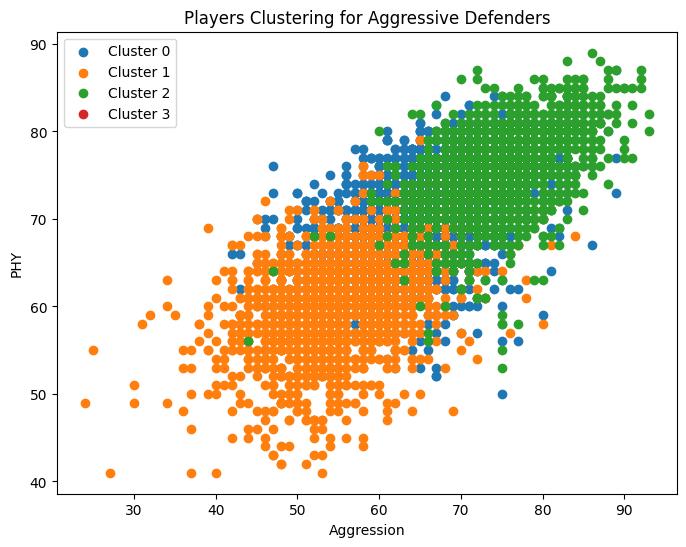

In [ ]:
#plot for Aggressive Defenders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = def_df_clean[def_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Aggression'], cluster_data['PHY'], label=f'Cluster {cluster}')
plt.xlabel('Aggression')
plt.ylabel('PHY')
plt.title('Players Clustering for Aggressive Defenders')
plt.legend()
plt.show()

In [ ]:
# the most aggressive and physical defenders
def_df_clean[def_df_clean['Cluster'] == 2].sort_values(by='Aggression', ascending=False)[['Name', 'Aggression', 'PHY', 'Position', 'Age Category']].head(10)


,Name,Aggression,PHY,Position
Rank,,,,
1888,Dominik Kohr,93,80,CB
5037,Klaus Gjasula,93,82,CB
5037,Maximiliano Falcón,92,87,CB
322,Gianluca Mancini,92,85,CB
40,Antonio Rüdiger,92,86,CB
1218,Ladislav Krejčí,91,85,CB
1525,Marcos Rojo,91,77,CB
149,Lisandro Martínez,91,81,CB
1218,Julian Chabot,91,83,CB


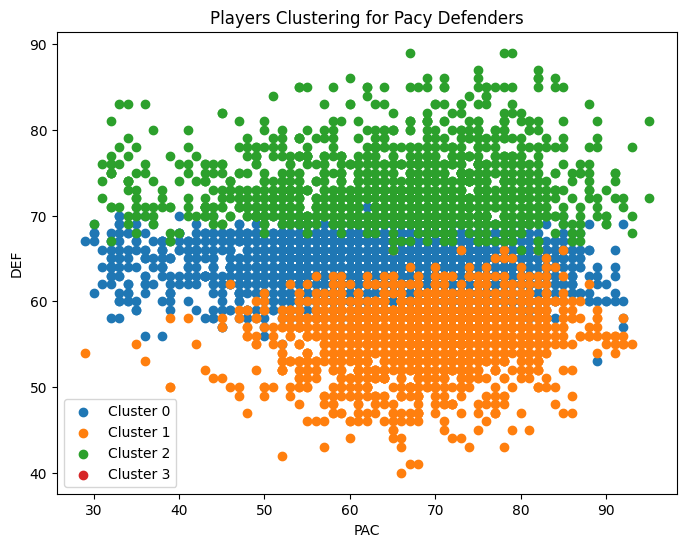

In [ ]:
#Plot for Pacy Defenders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = def_df_clean[def_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Sprint Speed'], cluster_data['Acceleration'], label=f'Cluster {cluster}')
plt.xlabel('Sprint Speed')
plt.ylabel('Acceleration')
plt.title('Players Clustering for Pacy Defenders')
plt.legend()
plt.show()

In [ ]:
def_df_clean[def_df_clean['Cluster'] == 2].sort_values(by='Sprint Speed', ascending=False)[['Name', 'Sprint Speed', 'Acceleration', 'Position', 'Age Category']].head(10)


,Name,PAC,DEF,Position
Rank,,,,
322,Alphonso Davies,95,72,LB
50,Theo Hernández,95,81,LB
1525,Bright Osayi-Samuel,93,68,RB
736,Manuel Lazzari,93,70,RB
1218,Jeremiah St. Juste,93,78,CB
970,Saud Abdulhamid,92,71,RB
970,Thierry Correia,92,72,RB
149,Achraf Hakimi,91,75,RB
736,Sergiño Dest,91,72,LB


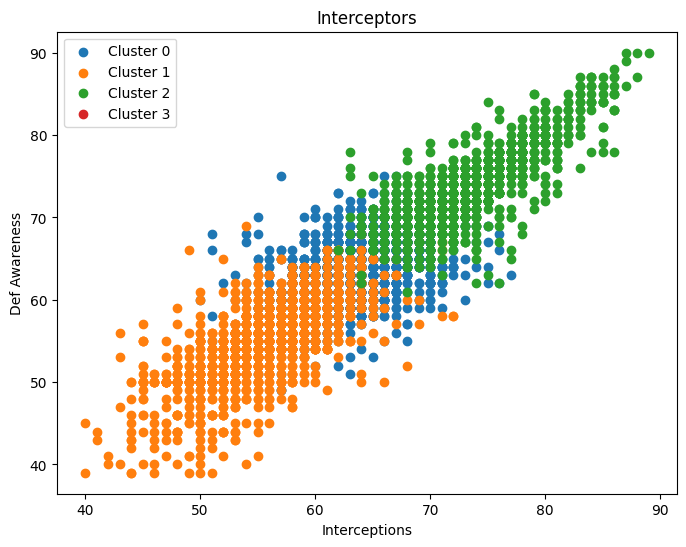

In [ ]:
#plot for Aggressive Defenders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = def_df_clean[def_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Interceptions'], cluster_data['Def Awareness'], label=f'Cluster {cluster}')
plt.xlabel('Interceptions')
plt.ylabel('Def Awareness')
plt.title('Interceptors')
plt.legend()
plt.show()

In [ ]:
def_df_clean[def_df_clean['Cluster'] == 2].sort_values(by='Interceptions', ascending=False)[['Name', 'Interceptions', 'Def Awareness', 'Position', 'Age Category']].head(10)


,Name,Interceptions,Def Awareness,Position
Rank,,,,
61,Marquinhos,89,90,CB
62,Alessandro Bastoni,88,87,CB
20,Virgil van Dijk,88,90,CB
101,David Alaba,87,89,CB
222,Stefan de Vrij,87,86,CB
29,Rúben Dias,87,90,CB
458,Yeray,86,83,CB
149,Benjamin Pavard,86,85,CB
2318,Florian Grillitsch,86,78,CB


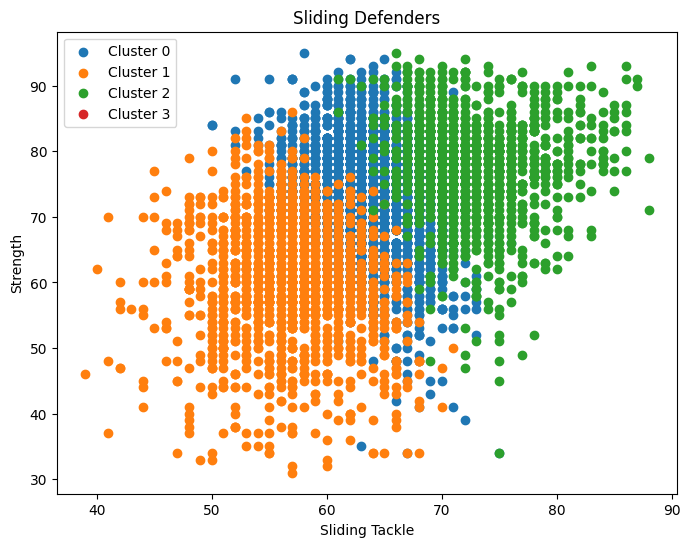

In [ ]:
#plot for Aggressive Defenders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = def_df_clean[def_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Sliding Tackle'], cluster_data['Strength'], label=f'Cluster {cluster}')
plt.xlabel('Sliding Tackle')
plt.ylabel('Strength')
plt.title('Sliding Defenders')
plt.legend()
plt.show()

In [ ]:
def_df_clean[def_df_clean['Cluster'] == 2].sort_values(by='Sliding Tackle', ascending=False)[['Name', 'Sliding Tackle', 'Strength', 'Position', 'Age Category']].head(10)


,Name,Sliding Tackle,Strength,Position
Rank,,,,
736,Aaron Wan-Bissaka,88,71,RB
61,Marquinhos,88,79,CB
29,Rúben Dias,87,90,CB
40,Antonio Rüdiger,87,91,CB
577,Ibañez,86,80,CB
20,Virgil van Dijk,86,93,CB
44,William Saliba,86,87,CB
69,Gabriel,86,86,CB
149,Matthijs de Ligt,86,91,CB


In [ ]:
df.columns

Index(['Name', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration',
       'Sprint Speed', 'Positioning', 'Finishing', 'Shot Power', 'Long Shots',
       'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
       'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility',
       'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions',
       'Heading Accuracy', 'Def Awareness', 'Standing Tackle',
       'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression',
       'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height',
       'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes', 'Age Category'],
      dtype='object')

Clustering for Midefielders to identify archetypes such as Shooting Midfielders and Defensive minded midfielders.

In [ ]:
#K-Means to group similar midfielders together
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

mid_positions = ['CM', 'CDM', 'LM', 'RM', 'CAM', 'LAM', 'RAM']
mid_df = df[df['Position'].isin(mid_positions)].copy()

#cluster based on attributes below
features = ['Long Passing', 'Dribbling', 'Ball Control', 'Long Shots', 'PAS', 'PHY', 'Strength', 'Agility', 'Short Passing', 'Free Kick Accuracy', 'Vision', 'Standing Tackle', 'DEF', 'SHO', 'Age Category']
mid_df_clean = mid_df.dropna(subset = features).copy() #removes rows with missing values in these columns

#Standardize the Data
#Since K-Means uses Euclidean distance (distance between two points), scaling is necessary
X = mid_df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

mid_df_clean['Cluster'] = cluster_labels

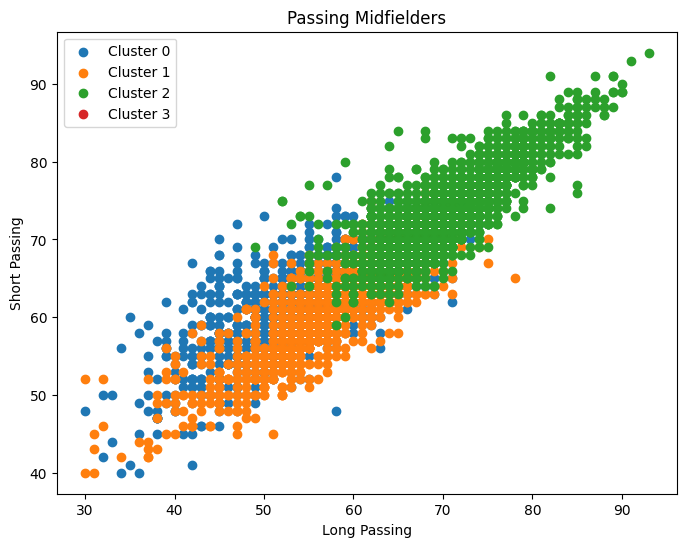

In [ ]:
#plot for Passing Midfielders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = mid_df_clean[mid_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Long Passing'], cluster_data['Short Passing'], label=f'Cluster {cluster}')
plt.xlabel('Long Passing')
plt.ylabel('Short Passing')
plt.title('Passing Midfielders')
plt.legend()
plt.show()

In [ ]:
mid_df_clean[mid_df_clean['Cluster'] == 2].sort_values(by='Long Passing', ascending=False)[['Name', 'Long Passing', 'Short Passing', 'Vision', 'Position', 'Age Category']].head(10)


,Name,Long Passing,Short Passing,Vision
Rank,,,,
9,Kevin De Bruyne,93,94,95
2,Rodri,91,93,84
70,Granit Xhaka,90,89,84
57,Bruno Fernandes,90,89,94
77,Luka Modrić,90,90,90
5,Jude Bellingham,89,89,90
12,Martin Ødegaard,89,91,91
100,Hakan Çalhanoğlu,89,89,89
322,Enzo Fernández,89,87,85


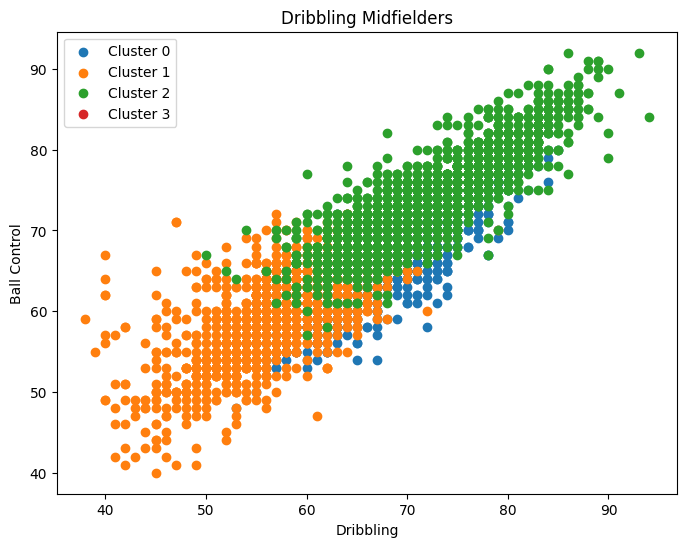

In [ ]:
#plot for Dribbling Midfielders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = mid_df_clean[mid_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Dribbling'], cluster_data['Ball Control'], label=f'Cluster {cluster}')
plt.xlabel('Dribbling')
plt.ylabel('Ball Control')
plt.title('Dribbling Midfielders')
plt.legend()
plt.show()

In [ ]:
mid_df_clean[mid_df_clean['Cluster'] == 2].sort_values(by='Dribbling', ascending=False)[['Name', 'Dribbling', 'Ball Control', 'Agility', 'Position', 'Age Category']].head(10)


,Name,Dribbling,Ball Control,Agility
Rank,,,,
46,Jamal Musiala,94,84,93
34,Bernardo Silva,93,92,95
322,Jadon Sancho,91,87,90
577,Allan Saint-Maximin,90,82,93
1888,Rayan Cherki,90,79,81
42,Florian Wirtz,90,90,87
222,Ángel Di María,89,90,88
322,Mohammed Kudus,89,84,86
49,Paulo Dybala,89,91,88


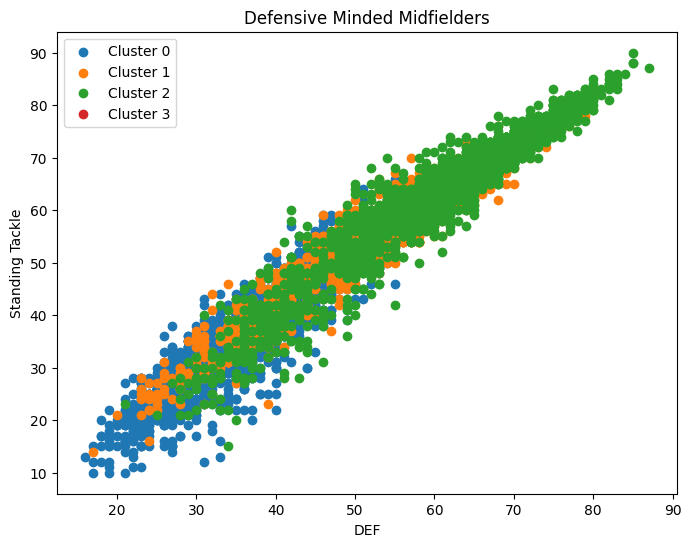

In [ ]:
#plot for Defensive Minded Midfielders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = mid_df_clean[mid_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['DEF'], cluster_data['Standing Tackle'], label=f'Cluster {cluster}')
plt.xlabel('DEF')
plt.ylabel('Standing Tackle')
plt.title('Defensive Minded Midfielders')
plt.legend()
plt.show()

In [ ]:
mid_df_clean[mid_df_clean['Cluster'] == 2].sort_values(by='DEF', ascending=False)[['Name', 'DEF', 'Standing Tackle', 'PHY', 'Age Category']].head(10)


,Name,DEF,Standing Tackle,PHY
Rank,,,,
2,Rodri,87,87,85
222,Guido Rodríguez,85,88,80
101,Palhinha,85,88,90
101,N'Golo Kanté,85,90,78
53,Declan Rice,84,86,85
458,Edson Álvarez,83,83,87
222,Robert Andrich,83,86,83
101,Mikel Merino,83,84,82
322,Boubacar Kamara,83,85,80


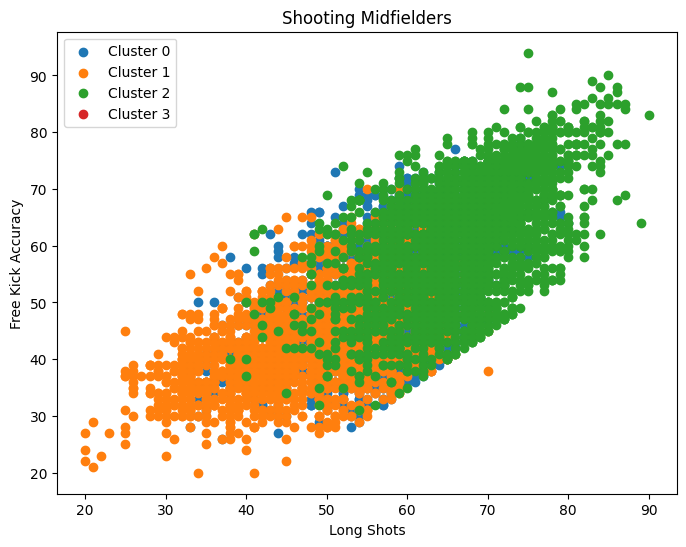

In [ ]:
#plot for Shooting Midfielders
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = mid_df_clean[mid_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Long Shots'], cluster_data['Free Kick Accuracy'], label=f'Cluster {cluster}')
plt.xlabel('Long Shots')
plt.ylabel('Free Kick Accuracy')
plt.title('Shooting Midfielders')
plt.legend()
plt.show()

In [ ]:
mid_df_clean[mid_df_clean['Cluster'] == 2].sort_values(by='Long Shots', ascending=False)[['Name', 'Long Shots', 'Free Kick Accuracy', 'SHO', 'Age Category']].head(10)


,Name,Long Shots,Free Kick Accuracy,SHO
Rank,,,,
9,Kevin De Bruyne,90,83,87
2,Rodri,89,64,80
100,Hakan Çalhanoğlu,87,85,80
149,Marcel Sabitzer,87,78,84
577,Maximilian Arnold,87,84,79
32,Federico Valverde,87,69,82
222,Ángel Di María,86,88,80
1525,Leonardo Fernández,86,85,79
5,Jude Bellingham,86,68,87


Clustering for Attackers to identify archetypes such as Agile forwards and Lethal finishers.

In [ ]:
#K-Means to group similar Attackers together
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

fw_positions = ['LW', 'ST', 'CF', 'RW']
fw_df = df[df['Position'].isin(fw_positions)].copy()

#cluster based on attributes below
features = ['Dribbling', 'Shot Power', 'Ball Control', 'Long Shots', 'Finishing', 'Heading Accuracy', 'Strength', 'Agility', 'Jumping', 'Reactions', 'SHO', 'Age Category']
fw_df_clean = fw_df.dropna(subset = features).copy() #removes rows with missing values in these columns

#Standardize the Data
#Since K-Means uses Euclidean distance (distance between two points), scaling is necessary
X = fw_df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

fw_df_clean['Cluster'] = cluster_labels

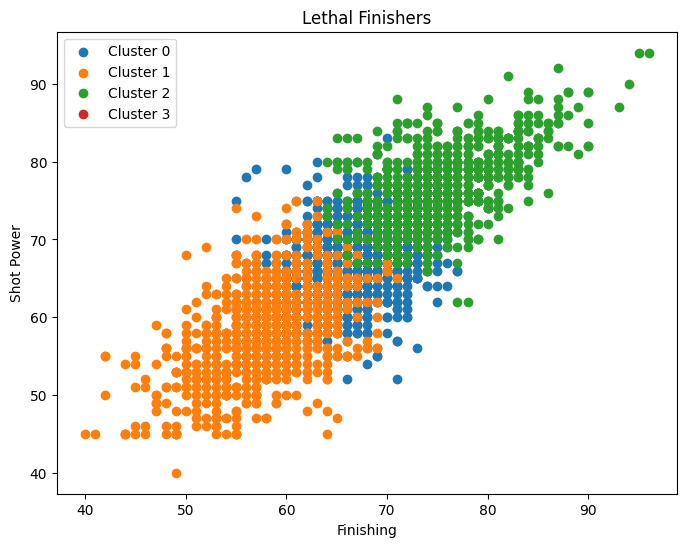

In [ ]:
#plot for Forwards lethal in front of goal
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = fw_df_clean[fw_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Finishing'], cluster_data['Shot Power'], label=f'Cluster {cluster}')
plt.xlabel('Finishing')
plt.ylabel('Shot Power')
plt.title('Lethal Finishers')
plt.legend()
plt.show()

In [ ]:
fw_df_clean[fw_df_clean['Cluster'] == 2].sort_values(by='Finishing', ascending=False)[['Name', 'Finishing', 'Shot Power', 'Position', 'Age Category']].head(10)


,Name,Finishing,Shot Power,Position
Rank,,,,
4,Erling Haaland,96,94,ST
11,Harry Kane,95,94,ST
1,Kylian Mbappé,94,90,ST
18,Lautaro Martínez,93,87,ST
30,Robert Lewandowski,90,89,ST
22,Mohamed Salah,90,82,RW
149,Iago Aspas,90,82,ST
28,Antoine Griezmann,90,85,ST
60,Heung Min Son,90,89,ST


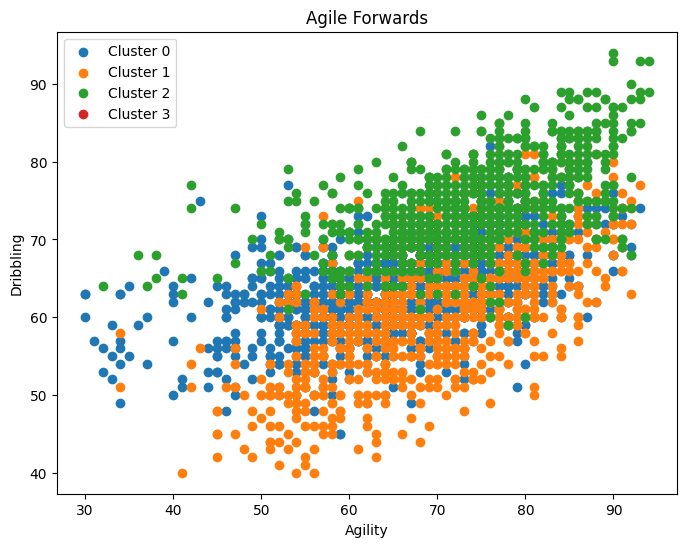

In [ ]:
#plot for Agile Forwards in front of goal
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = fw_df_clean[fw_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Agility'], cluster_data['Dribbling'], label=f'Cluster {cluster}')
plt.xlabel('Agility')
plt.ylabel('Dribbling')
plt.title('Agile Forwards')
plt.legend()
plt.show()

In [ ]:
fw_df_clean[fw_df_clean['Cluster'] == 2].sort_values(by='Agility', ascending=False)[['Name', 'Agility', 'Dribbling', 'Reactions', 'Position', 'Age Category']].head(10)


,Name,Agility,Dribbling,Reactions,Position
Rank,,,,,
7,Vini Jr.,94,93,86,LW
83,Ousmane Dembélé,94,89,82,RW
222,Mattia Zaccagni,93,88,83,LW
577,Jérémy Doku,93,89,77,LW
1218,Jonathan Ikoné,93,85,73,RW
1,Kylian Mbappé,93,93,93,ST
3521,Frank Acheampong,92,78,74,ST
736,Marcus Edwards,92,85,78,RW
222,Leandro Trossard,92,84,80,LW


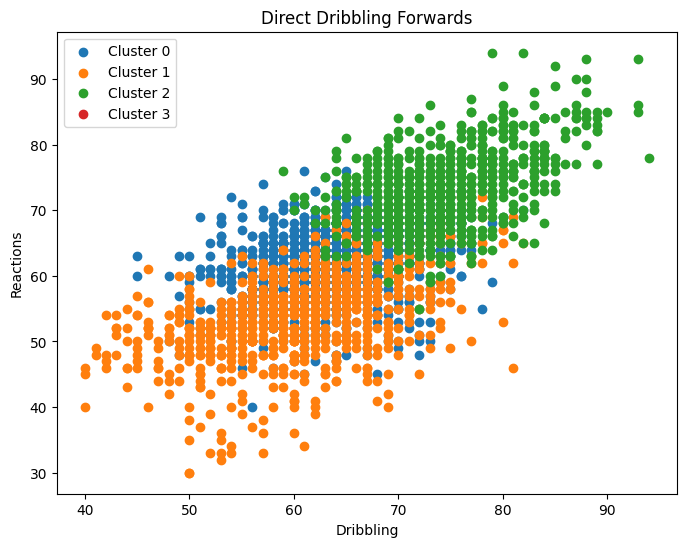

In [ ]:
#plot for Direct Dribbling Forwards in front of goal
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = fw_df_clean[fw_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Dribbling'], cluster_data['Reactions'], label=f'Cluster {cluster}')
plt.xlabel('Dribbling')
plt.ylabel('Reactions')
plt.title('Direct Dribbling Forwards')
plt.legend()
plt.show()

In [ ]:
fw_df_clean[fw_df_clean['Cluster'] == 2].sort_values(by='Dribbling', ascending=False)[['Name', 'Dribbling', 'Ball Control', 'Position', 'Age Category']].head(10)


,Name,Dribbling,Ball Control,Position
Rank,,,,
52,Neymar Jr,94,93,LW
7,Vini Jr.,93,90,LW
1,Kylian Mbappé,93,92,ST
25,Lionel Messi,93,93,RW
23,Phil Foden,90,91,RW
72,Rodrygo,89,87,RW
47,Bukayo Saka,89,88,RW
149,Luis Díaz,89,87,LW
83,Ousmane Dembélé,89,87,RW


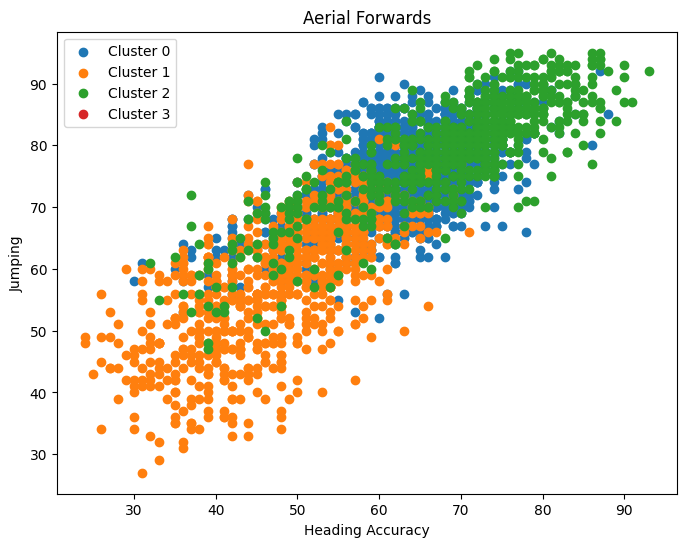

In [ ]:
#plot for Aerial Forwards in front of goal
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = fw_df_clean[fw_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Heading Accuracy'], cluster_data['Jumping'], label=f'Cluster {cluster}')
plt.xlabel('Heading Accuracy')
plt.ylabel('Jumping')
plt.title('Aerial Forwards')
plt.legend()
plt.show()

In [ ]:
fw_df_clean[fw_df_clean['Cluster'] == 2].sort_values(by='Heading Accuracy', ascending=False)[['Name', 'Heading Accuracy', 'Jumping', 'Strength', 'Position', 'Age Category']].head(10)


,Name,Heading Accuracy,Jumping,Strength,Position
Rank,,,,,
458,Luuk de Jong,93,92,85,ST
11,Harry Kane,91,87,86,ST
222,Mauro Icardi,90,87,79,ST
222,Youssef En-Nesyri,90,93,79,ST
322,Aleksandar Mitrović,90,91,91,ST
222,Olivier Giroud,89,84,93,ST
322,Niclas Füllkrug,89,89,86,ST
30,Robert Lewandowski,88,92,89,ST
1525,Paul Ebere Onuachu,87,82,92,ST


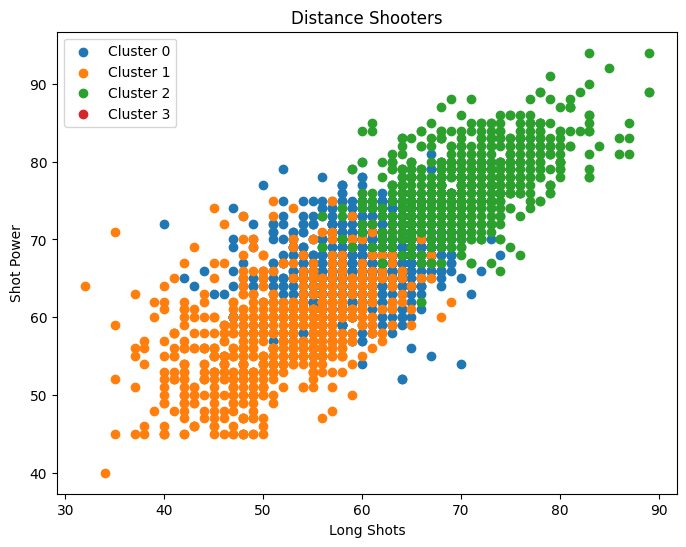

In [ ]:
#plot for Distance Shooter in front of goal
plt.figure(figsize=(8,6))
for cluster in range(4):
  cluster_data = fw_df_clean[fw_df_clean['Cluster'] == cluster]
  plt.scatter(cluster_data['Long Shots'], cluster_data['Shot Power'], label=f'Cluster {cluster}')
plt.xlabel('Long Shots')
plt.ylabel('Shot Power')
plt.title('Distance Shooters')
plt.legend()
plt.show()

In [ ]:
fw_df_clean[fw_df_clean['Cluster'] == 2].sort_values(by='Long Shots', ascending=False)[['Name', 'Long Shots', 'Shot Power', 'SHO', 'Position', 'Age Category']].head(10)


,Name,Long Shots,Shot Power,SHO,Position
Rank,,,,,
11,Harry Kane,89,94,93,ST
23,Phil Foden,89,89,86,RW
60,Heung Min Son,89,89,89,ST
28,Antoine Griezmann,87,85,88,ST
25,Lionel Messi,87,83,85,RW
458,Marco Asensio,87,81,79,RW
322,Ángel Correa,86,83,84,ST
736,İrfan Can Kahveci,86,81,79,RW
68,Cristiano Ronaldo,85,92,88,ST


##Regression Modeling
Here we build a linear and random forest regression models to predict a player's OVR based on six key in-game attributes. This helps us understand which specific traits most influence overall performance.

In [ ]:
#selecting only the relevant features for prediction
#drop rows with missing values since models can't train on NAN
cols = ['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']
df = df[cols].dropna()

In [ ]:
#x contains input values that I think influence the target variable
X = df[['PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']]
y = df['OVR'] #overall rating is what I'm trying to predict

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#the data is split to evaluate how well the model works. training is 80% and testing 20% by default

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler() #scale to mean 0 and std 1
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#0.77 is a good result. maybe additional of more attributes like experience might improve it
#an RMSE of 3.21 is fairly good
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print('Linear Regression R2:', r2_score(y_test, y_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.7763116325563306
RMSE: 3.21285390784969


In [ ]:
#Random forest model
#96% of the variance in players' OVR is based on the features provided
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#R2 close to 1 means the performance is excellent. Random Forest performed better
y_pred_rf = rf.predict(X_test)
print('Random Forest R2:', r2_score(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: 0.9683374579892718
RMSE: 1.2087658106636638


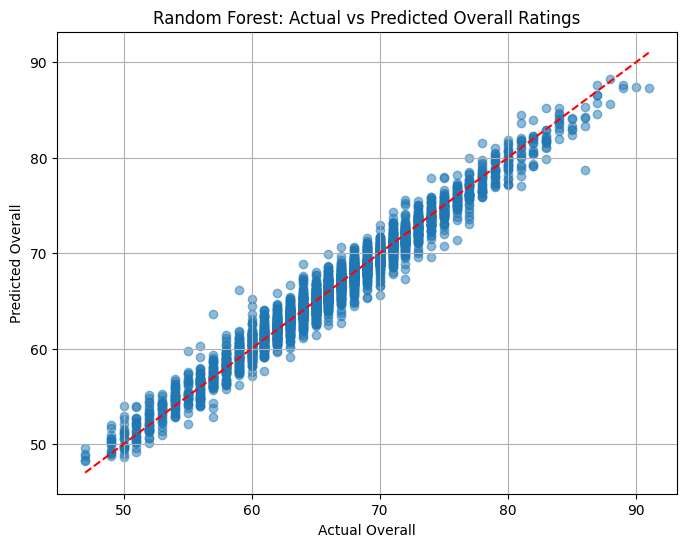

In [ ]:
#plot the random forest results to determine actual vs predicted values. results look good
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel('Actual Overall')
plt.ylabel('Predicted Overall')
plt.title('Random Forest: Actual vs Predicted Overall Ratings')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid(True)
plt.show()